# Personalization signal analysis

**Purpose:** decide, from Silver data, which customer-level signals justify a `gold.customer_personalization_profile` table -- before designing that table.

This does not build the recommender or the Gold table. It measures, for every candidate personalization signal the team discussed:

- **Coverage** -- what fraction of customers in `dim_customers` actually have the signal. Fact IDs missing from the dimension are reported as orphans and never counted.
- **Consistency** -- when the same fact is recorded in more than one table (e.g. accent), do the sources agree?
- **Domain** -- the real distinct values, not the ones assumed from the data dictionary.
- **Language reality** -- the hackathon requires Spanish *and* Portuguese; this checks what the dataset actually contains before any Portuguese-specific personalization is designed.

Risk-scoring signals (`credit_score`, `estimated_monthly_income`, `fraud_score`, `days_past_due`) are deliberately **out of scope** -- the team decided personalization should not run through those fields.

All queries are in `personalization_metrics.measure` (read-only connection, no writes). Every *Reading* below is generated from the measured values.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown

plt.rcParams["figure.dpi"] = 110


def find_project_root(start: Path) -> Path:
    """Walk up from the kernel's working directory to the repository root."""
    for candidate in (start, *start.parents):
        if (candidate / "data_profiles" / "personalization_profile" / "personalization_metrics.py").is_file():
            return candidate
    raise FileNotFoundError("Run from inside the repository or set PROJECT_ROOT")


PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT") or find_project_root(Path.cwd().resolve())).resolve()
sys.path.insert(0, str(PROJECT_ROOT / "data_profiles" / "personalization_profile"))
import personalization_metrics as pm

DUCKDB_PATH = pm.resolve_duckdb_path()
print("Using DuckDB file:", pm.display_path(DUCKDB_PATH))
with pm.connect(DUCKDB_PATH) as con:
    m = pm.measure(con)
r = pm.readings(m)
total_customers = m["total_customers"]
print(f"Total customers: {total_customers:,}")


def frame(rows, columns):
    return pd.DataFrame(rows, columns=columns).fillna("(null)")


def bars(ax, rows, title, color="#2b6cb0"):
    ax.bar(["(null)" if k is None else str(k) for k, *_ in rows], [n for _, n, *_ in rows], color=color)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)

Using DuckDB file: data/full_local/latam_bank.duckdb


Total customers: 150,000


## 1. Signal coverage per customer (cold-start exposure)

How many customers actually have each type of history at all? A signal with low coverage cannot personalize most customers' first contact.

In [2]:
coverage = pd.DataFrame(m["coverage"]).sort_values("pct")
coverage

,source,customers,pct,orphan_ids
2,fact_complaints,54145,36.1,0
1,fact_call_transcripts,101951,68.0,0
3,fact_satisfaction_surveys,113640,75.8,0
5,fact_transactions,134515,89.7,0
0,fact_call_center_interactions,148443,99.0,0
4,fact_digital_events,149997,100.0,0


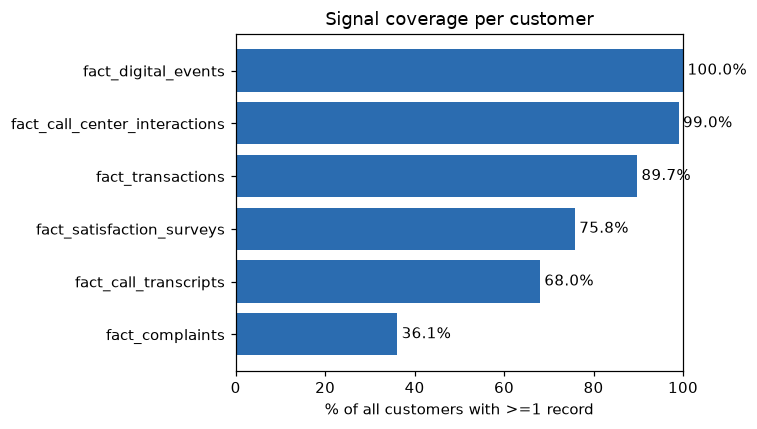

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(coverage["source"], coverage["pct"], color="#2b6cb0")
ax.set_xlabel("% of all customers with >=1 record")
ax.set_title("Signal coverage per customer")
ax.set_xlim(0, 100)
for y, v in enumerate(coverage["pct"]):
    ax.text(v + 1, y, f"{v}%", va="center")
plt.tight_layout()
plt.show()

In [4]:
Markdown("**Reading:** " + r["coverage"])

**Reading:** Every customer has at least one interaction, complaint or digital event, so there is no fully cold-start population. Coverage is below 80% for `fact_call_transcripts` (68.0%), `fact_complaints` (36.1%), `fact_satisfaction_surveys` (75.8%); those sources can refine a profile but cannot be any customer's only signal. No fact customer ID is missing from `dim_customers`.

## 2. Accent signal: domain and cross-source agreement

The dataset records accent in three places. Do they agree enough to trust one as the source of truth?

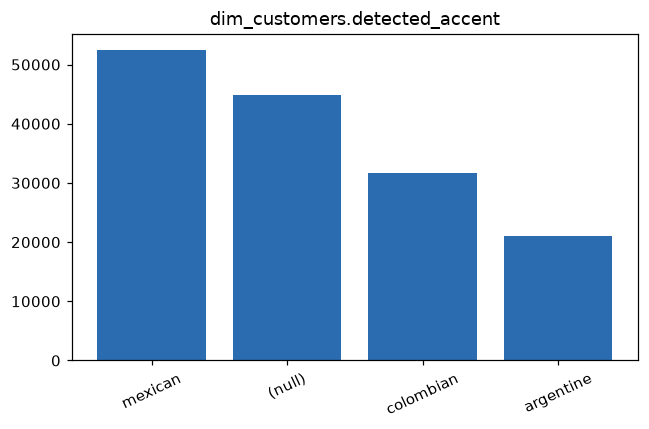

,detected_accent,customers
0,mexican,52505
1,(null),44817
2,colombian,31666
3,argentine,21012


In [5]:
accent_dim = frame(m["accent_dim"], ["detected_accent", "customers"])
fig, ax = plt.subplots(figsize=(6, 4))
bars(ax, m["accent_dim"], "dim_customers.detected_accent")
plt.tight_layout()
plt.show()
accent_dim

In [6]:
pd.DataFrame([m["accent_agreement"] | {"blank_profile_accent": m["blank_accent"]}])

,compared,agree,pct,blank_profile_accent
0,104096,104096,100.0,44817


In [7]:
Markdown("**Reading:** " + r["accent"])

**Reading:** Where both exist (104,096 customers) the profile accent matches the most common interaction accent every time, so `dim_customers.detected_accent` can be trusted when present. The profile accent is blank for 44,817 customers (29.9%), so the profile needs a fallback chain: `dim_customers` -> mode of interaction accent -> mode of transcript accent -> null (never a guessed default).

## 3. Language domain: Spanish/Portuguese requirement check

The hackathon requires demonstrating Spanish **and** Portuguese. This checks what language the transcripts actually contain.

In [8]:
frame(m["languages"], ["detected_language", "transcripts"])

,detected_language,transcripts
0,es,171321


In [9]:
Markdown("**Reading:** " + r["language"])

**Reading:** None of the 171,321 transcripts has a Portuguese `detected_language`. Portuguese personalization cannot be derived or validated from this dataset; it has to be demonstrated with hand-authored cases and reported as a data limitation.

## 4. Segment, country, and digital-channel domains

The real distinct values behind the categorical fields a tone/style rule would key off.

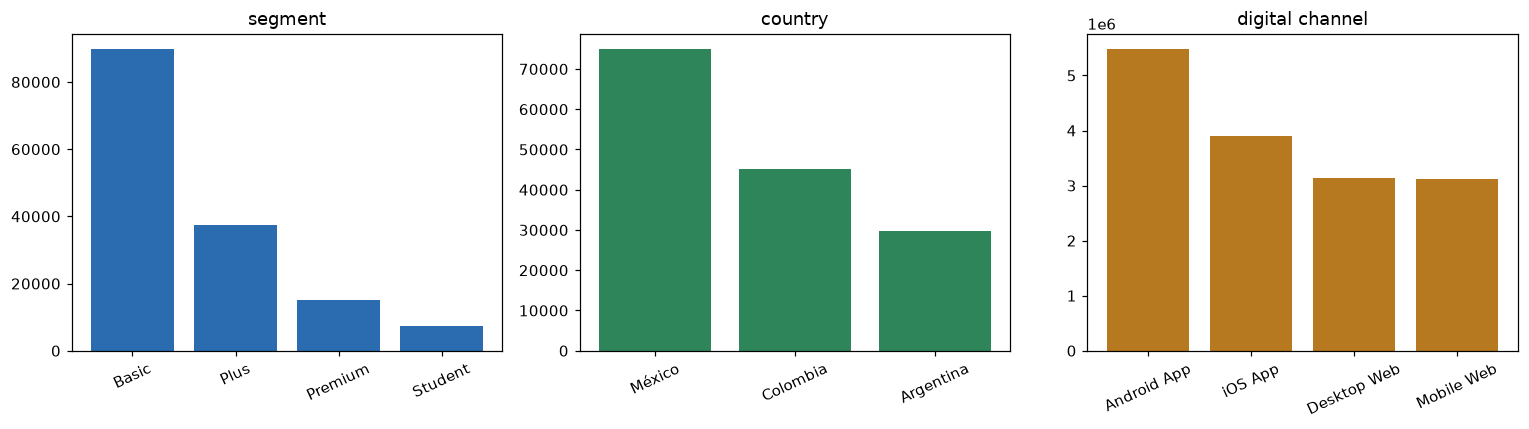

,segment,customers
0,Basic,89756
1,Plus,37547
2,Premium,15207
3,Student,7490


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bars(axes[0], m["segments"], "segment")
bars(axes[1], m["countries"], "country", "#2f855a")
bars(axes[2], m["channels"], "digital channel", "#b7791f")
plt.tight_layout()
plt.show()
frame(m["segments"], ["segment", "customers"])

In [11]:
Markdown("**Reading:** " + r["segment"])

**Reading:** Segment shares: `Basic` 59.8%, `Plus` 25.0%, `Premium` 10.1%, `Student` 5.0%. The smallest segment (`Student`) has the least evidence for any segment-based tone rule. Segment is a current snapshot, not the segment at the time of past contacts.

In [12]:
Markdown("**Reading:** " + r["country_channel"])

**Reading:** Countries: `México` 49.9%, `Colombia` 30.2%, `Argentina` 19.9%. Digital channels: `Android App` 35.1%, `iOS App` 25.0%, `Desktop Web` 20.0%, `Mobile Web` 20.0% of 15,620,994 events.

## 5. Repeat-contact and open-complaint signal strength

How often would a 'you've contacted us about this before' or 'you have an open case' personalization actually trigger?

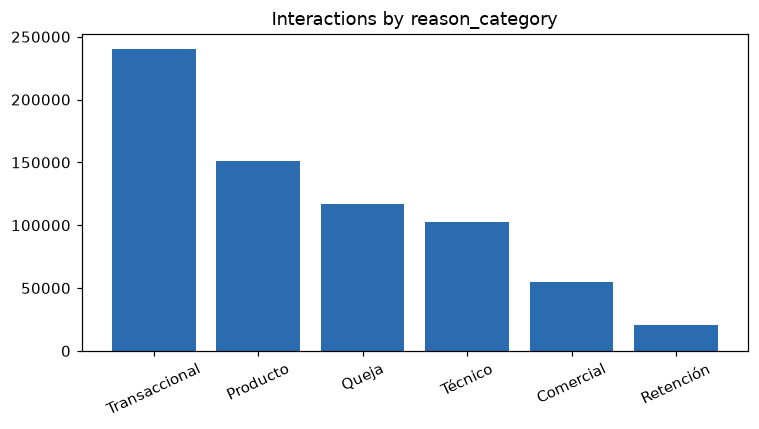

,reason_category,interactions,customers
0,Transaccional,240056,119646
1,Producto,150863,95245
2,Queja,117021,81336
3,Técnico,102899,74536
4,Comercial,54879,45979
5,Retención,20578,19274


In [13]:
reasons = frame(m["reasons"], ["reason_category", "interactions", "customers"])
fig, ax = plt.subplots(figsize=(7, 4))
bars(ax, m["reasons"], "Interactions by reason_category")
plt.tight_layout()
plt.show()
reasons

In [14]:
Markdown("**Reading:** " + r["repeat"])

**Reading:** 112,359 customers (74.9%) have >=2 interactions in the same `reason_category` (ever, not windowed). 42,726 (28.5%) currently have an open, in-process or escalated complaint; complaint status is a snapshot.

## 6. Sentiment and CSAT coverage

Is sentiment/satisfaction data clean enough to summarize per customer?

In [15]:
frame(m["surveys"], ["survey_type", "surveys", "avg_main_score", "min", "max"])

,survey_type,surveys,avg_main_score,min,max
0,CSAT,127856,2.77,1,4
1,NPS,63668,5.31,2,7
2,CES,21235,2.77,1,4


In [16]:
Markdown("**Reading:** " + r["sentiment"])

**Reading:** `sentiment_score` is null for 0/686,296 interactions (0.0%) and present for 148,443 customers (99.0%). `main_score` ranges per survey type: `CSAT` 1-4; `NPS` 2-7; `CES` 1-4. It must not be averaged across types; use one column per type.

## 7. Consent gate for proactive personalization

In [17]:
frame(m["consent"], ["accepts_marketing", "customers"])

,accepts_marketing,customers
0,False,75007
1,True,74993


In [18]:
Markdown("**Reading:** " + r["consent"])

**Reading:** `accepts_marketing`: True 50.0%, False 50.0%, null 0. It is the current consent snapshot, so it can gate proactive personalization now but says nothing about consent at past contact dates. Reactive personalization (answering what the customer asked) does not need this gate.

## 8. Recommended variables for `gold.customer_personalization_profile`

Evidence is filled from the measurements above. None of these signals requires joining fact tables to each other directly -- each is aggregated to `customer_id` grain independently before any join, per the project's join-safety rule.

In [19]:
pd.DataFrame(pm.recommended(m), columns=["Variable", "Source", "Evidence", "Decision"])

,Variable,Source,Evidence,Decision
0,preferred_accent,dim_customers -> interaction mode -> transcrip...,"100.0% agreement over 104,096 comparable custo...","Include, with the 3-step fallback and null as ..."
1,preferred_language,call_transcripts.detected_language,"0.0% Portuguese of 171,321 transcripts",Include for Spanish only; Portuguese is a docu...
2,"segment, country",dim_customers,"0 null segments, 0 null countries; current sna...","Include directly as tone inputs, never for eli..."
3,preferred_digital_channel,mode of fact_digital_events.channel,"100.0% customer coverage; 4 channels over 15,6...",Include
4,repeat_contact_flag,fact_call_center_interactions by reason_category,74.9% of customers qualify,Include
5,open_complaint_flag,fact_complaints.status (snapshot),28.5% of customers,Include
6,avg_sentiment_score,fact_call_center_interactions.sentiment_score,0.0% null; 99.0% customer coverage,Include
7,csat_avg / nps_avg / ces_avg,"fact_satisfaction_surveys, split by survey_type",3 survey types on different scales,"Include as separate columns, never blended"
8,accepts_marketing,dim_customers (current snapshot),"True 50.0%, null 0","Include as a gate for proactive offers, not a ..."
9,"credit_score, estimated_monthly_income, fraud_...",dim_customers / products / transactions,Out of scope by team decision,Excluded
